In [249]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick


# Modelos

## Preprocesamiento 2

In [286]:
ctv_01 = CoxTimeVaryingFitter()
ctv_01.fit(df_oo, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv_01.print_summary()

coef_01 = ctv_01.params_
conf_01 = ctv_01.confidence_intervals_

Iteration 1: norm_delta = 8.50e-01, step_size = 0.9500, log_lik = -2591.43092, newton_decrement = 6.24e+01, seconds_since_start = 0.8
Iteration 2: norm_delta = 9.29e-02, step_size = 0.9500, log_lik = -2536.95181, newton_decrement = 2.72e+00, seconds_since_start = 1.7
Iteration 3: norm_delta = 2.12e-02, step_size = 0.9500, log_lik = -2533.98389, newton_decrement = 1.73e-01, seconds_since_start = 2.6
Iteration 4: norm_delta = 3.11e-03, step_size = 1.0000, log_lik = -2533.80319, newton_decrement = 2.94e-03, seconds_since_start = 3.5
Iteration 5: norm_delta = 3.72e-05, step_size = 1.0000, log_lik = -2533.80023, newton_decrement = 4.15e-07, seconds_since_start = 4.4
Iteration 6: norm_delta = 5.31e-09, step_size = 1.0000, log_lik = -2533.80023, newton_decrement = 8.44e-15, seconds_since_start = 5.2
Convergence completed after 6 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 204579 periods, 108713 subjects, 226 events>
         event col = 'event'
number of subjects = 108713
 number of periods = 204579
  number of events = 226
partial log-likelihood = -2533.80
  time fit was run = 2024-08-21 12:02:49 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
inmunizado    -1.28      0.28      0.15           -1.57           -0.99                0.21                0.37
si_3_meses    -0.89      0.41      0.15           -1.18           -0.60                0.31                0.55
SEXO           0.37      1.45      0.14            0.10            0.64                1.11                1.89
muy_prematuro  1.11      3.03      0.34            0.44            1.77                1.55                5.90

               cmp to     z      p  -log2(p)
covariate                                   
inmunizado       0.00 -8.56 <0.005     56.29
si_3_meses       0.00 -6.09 <0.005     29.68
SEXO             0.00  2.72   0.01      7.27
muy_prematuro    0.00  3.26 <0.005      9.79
---
Partial AIC = 5075.60
log-likelihood ratio test = 115.26 on 4 df
-log2(p) of ll-ratio test = 77.27

In [ ]:
print(coef_01)

covariate
inmunizado      -1.275327
si_3_meses      -0.971842
SEXO             0.399405
muy_prematuro    1.020640
dtype: float64


In [ ]:
print(conf_01)

               95% lower-bound  95% upper-bound
covariate                                      
inmunizado           -1.595512        -0.955142
si_3_meses           -1.286653        -0.657031
SEXO                  0.110100         0.688710
muy_prematuro         0.265573         1.775708


In [ ]:
# Datos
x_values = [21, 22, 23, 24]  # Eje X
y_values = [-1.76, -1.48, -1.42, -1.28]  # Eje Y
conf_intervals = [[-2.23, -1.30], [-1.88, -1.08], [-1.77, -1.07], [-1.57, -0.99]]  # Intervalos de confianza
conf_intervals = 1-np.exp(conf_intervals)

# Extraer los valores inferiores y superiores de los intervalos de confianza
lower_bounds = [ci[0] for ci in conf_intervals]
upper_bounds = [ci[1] for ci in conf_intervals]

# Graficar los puntos con intervalos de confianza
plt.errorbar(x_values, (1-np.exp(y_values)), yerr=[(y1 - y2) for y1, y2 in zip((1-np.exp(y_values)), lower_bounds)], 
             fmt='o', capsize=5, capthick=2, markeredgewidth=2, label='Valores con IC')

# Configuración del gráfico
plt.xlabel('X')
plt.ylabel('Valores con Intervalos de Confianza')
plt.title('Gráfico de Puntos con Intervalos de Confianza')
plt.grid(True)
plt.show()

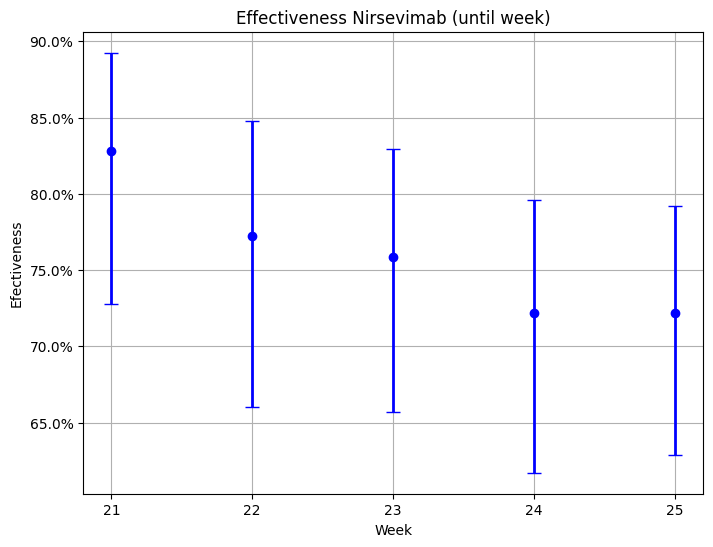

In [299]:
# Datos originales

x_values = [21, 22, 23, 24, 25]
y_values = [-1.76, -1.48, -1.42,-1.28, -1.28]
conf_intervals = [[-2.23, -1.30], [-1.88, -1.08], [-1.77, -1.07], [-1.59, -0.96], [-1.57, -0.99]]

# Aplicar la transformación 1 - exp(y) a los valores y
y_transformed = [1 - np.exp(y) for y in y_values]
conf_intervals_transformed = [[1 - np.exp(ci[1]), 1 - np.exp(ci[0])] for ci in conf_intervals]

# Crear las barras de error a partir de los intervalos de confianza transformados
yerr_low = [yt - ci[0] for yt, ci in zip(y_transformed, conf_intervals_transformed)]
yerr_high = [ci[1] - yt for yt, ci in zip(y_transformed, conf_intervals_transformed)]

# Graficar
plt.figure(figsize=(8, 6))
plt.errorbar(x_values, y_transformed, yerr=[yerr_low, yerr_high], fmt='o', capsize=5, color='blue', lw=2)

plt.xticks(x_values)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
# Configuración del gráfico
plt.xlabel('Week')
plt.ylabel('Efectiveness')
plt.title('Effectiveness Nirsevimab (until week)')
plt.grid(True)
plt.show()


## Modelo_0 UPC

In [1242]:
df_f=dfs[26]
df_f.shape[0]

109013

In [1243]:
df_f['event'] = (df_f['fecha_upc'].notna()) & (df_f['VRS']==1)

In [1244]:
print("inmunes vrs upc:", df_f[(df_f['event']==1) & (df_f['inmunizado']==1)].shape[0])
print("no inmunes vrs upc:",df_f[(df_f['event']==1) & (df_f['inmunizado']==0)].shape[0])

inmunes vrs upc: 17
no inmunes vrs upc: 26


In [1245]:
df_f.loc[ (~df_f['event']), 'fecha_upc'] = pd.NaT
df_f.loc[(df_f['FECHA_INMUNIZACION'] >= df_f['fecha_upc']) & (df_f.event ==1 ), 'FECHA_INMUNIZACION'] = pd.NaT

In [1246]:
base_df = df_f[['RUN','FECHA_NAC','FECHA_INMUNIZACION','FECHA_ING','fecha_upc','inmunizado','group','prematuro','event','age_3m','age_6m','si_3_meses','si_6_meses']]
base_df = base_df.sort_values(by='event')
base_df

,RUN,FECHA_NAC,FECHA_INMUNIZACION,FECHA_ING,fecha_upc,inmunizado,group,prematuro,event,age_3m,age_6m,si_3_meses,si_6_meses
208,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,2024-02-20,NaT,2024-04-27,NaT,0,CATCH_UP,0,False,NaT,NaT,0,0
77233,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,2024-03-21,2024-04-04,NaT,NaT,1,CATCH_UP,0,False,NaT,NaT,0,0
77232,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,2024-03-23,2024-04-15,NaT,NaT,1,CATCH_UP,0,False,NaT,NaT,0,0
77231,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,2024-03-12,2024-04-30,NaT,NaT,1,CATCH_UP,0,False,NaT,NaT,0,0
77230,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,2024-03-20,NaT,NaT,NaT,0,CATCH_UP,1,False,NaT,NaT,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43380,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,2024-01-08,2024-04-10,2024-05-08,2024-05-08,1,CATCH_UP,0,True,2024-04-08,NaT,1,0
43291,9a5b6c73c780f7bf9c6fd74cda84ed6dc7713a90ba51d6...,2024-01-09,NaT,2024-05-31,2024-05-31,0,CATCH_UP,0,True,2024-04-09,NaT,1,0
78796,48db1def0f9b13b21aa74d99cc6426bc10db720e609695...,2024-03-26,NaT,2024-05-31,2024-05-31,0,CATCH_UP,1,True,NaT,NaT,0,0
32146,df8a9a6bcfcfbb06336e62b3e9876ce3d7c787bb72b980...,2023-12-14,NaT,2024-04-09,2024-04-09,0,CATCH_UP,0,True,2024-03-14,NaT,1,0


In [1247]:
vrs = base_df[base_df.event == 1]
df_vrs = base_df[base_df.RUN.isin(vrs.RUN.unique())]
df_vrs = df_vrs.drop_duplicates(subset=['RUN'], keep='last')
base_df = base_df[~base_df.RUN.isin(vrs.RUN.unique())]
base_df = pd.concat([base_df,df_vrs])
base_df

,RUN,FECHA_NAC,FECHA_INMUNIZACION,FECHA_ING,fecha_upc,inmunizado,group,prematuro,event,age_3m,age_6m,si_3_meses,si_6_meses
208,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,2024-02-20,NaT,2024-04-27,NaT,0,CATCH_UP,0,False,NaT,NaT,0,0
77233,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,2024-03-21,2024-04-04,NaT,NaT,1,CATCH_UP,0,False,NaT,NaT,0,0
77232,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,2024-03-23,2024-04-15,NaT,NaT,1,CATCH_UP,0,False,NaT,NaT,0,0
77231,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,2024-03-12,2024-04-30,NaT,NaT,1,CATCH_UP,0,False,NaT,NaT,0,0
77230,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,2024-03-20,NaT,NaT,NaT,0,CATCH_UP,1,False,NaT,NaT,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43380,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,2024-01-08,2024-04-10,2024-05-08,2024-05-08,1,CATCH_UP,0,True,2024-04-08,NaT,1,0
43291,9a5b6c73c780f7bf9c6fd74cda84ed6dc7713a90ba51d6...,2024-01-09,NaT,2024-05-31,2024-05-31,0,CATCH_UP,0,True,2024-04-09,NaT,1,0
78796,48db1def0f9b13b21aa74d99cc6426bc10db720e609695...,2024-03-26,NaT,2024-05-31,2024-05-31,0,CATCH_UP,1,True,NaT,NaT,0,0
32146,df8a9a6bcfcfbb06336e62b3e9876ce3d7c787bb72b980...,2023-12-14,NaT,2024-04-09,2024-04-09,0,CATCH_UP,0,True,2024-03-14,NaT,1,0


In [1248]:
base_df[base_df['fecha_upc']<base_df['FECHA_NAC']]

,RUN,FECHA_NAC,FECHA_INMUNIZACION,FECHA_ING,fecha_upc,inmunizado,group,prematuro,event,age_3m,age_6m,si_3_meses,si_6_meses


In [1249]:
T_inicial = pd.to_datetime('2024-03-31')
T_0_inmune = pd.to_datetime(df['FECHA_INMUNIZACION'].min())
T_0_inmune = df['FECHA_INMUNIZACION'].min()
#T_final_inmune = df['FECHA_INMUNIZACION'].max()

#base_df['long_inmune'] = (base_df['FECHA_INMUNIZACION'] - T_0_inmune).dt.days
base_df['age_3m'] = (base_df['age_3m'] - T_inicial).dt.days
base_df['age_6m'] = (base_df['age_6m'] - T_inicial).dt.days
base_df['FECHA_INMUNIZACION'] = (base_df['FECHA_INMUNIZACION'] - T_inicial).dt.days
base_df['FECHA_ING'] = (base_df['FECHA_ING'] - T_inicial).dt.days
base_df['FECHA_NAC'] = (base_df['FECHA_NAC'] - T_inicial).dt.days
base_df['fecha_upc'] = (base_df['fecha_upc'] - T_inicial).dt.days

base_df['start'] = np.where(base_df['group']=="CATCH_UP", 0, base_df['FECHA_NAC'])

base_df['age_3m'] = np.where(base_df['age_3m']<=0, 0, base_df['age_3m'])
base_df['age_6m'] = np.where(base_df['age_6m']<=0, 0, base_df['age_6m'])
#base_df['si_3_meses'] = np.ones(len(base_df))


base_df

,RUN,FECHA_NAC,FECHA_INMUNIZACION,FECHA_ING,fecha_upc,inmunizado,group,prematuro,event,age_3m,age_6m,si_3_meses,si_6_meses,start
208,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,-40,NaN,27.0,NaN,0,CATCH_UP,0,False,NaN,NaN,0,0,0
77233,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,-10,4.0,NaN,NaN,1,CATCH_UP,0,False,NaN,NaN,0,0,0
77232,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,-8,15.0,NaN,NaN,1,CATCH_UP,0,False,NaN,NaN,0,0,0
77231,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,-19,30.0,NaN,NaN,1,CATCH_UP,0,False,NaN,NaN,0,0,0
77230,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,-11,NaN,NaN,NaN,0,CATCH_UP,1,False,NaN,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43380,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,-83,10.0,38.0,38.0,1,CATCH_UP,0,True,8.0,NaN,1,0,0
43291,9a5b6c73c780f7bf9c6fd74cda84ed6dc7713a90ba51d6...,-82,NaN,61.0,61.0,0,CATCH_UP,0,True,9.0,NaN,1,0,0
78796,48db1def0f9b13b21aa74d99cc6426bc10db720e609695...,-5,NaN,61.0,61.0,0,CATCH_UP,1,True,NaN,NaN,0,0,0
32146,df8a9a6bcfcfbb06336e62b3e9876ce3d7c787bb72b980...,-108,NaN,9.0,9.0,0,CATCH_UP,0,True,0.0,NaN,1,0,0


In [1250]:
df_model = pd.melt(base_df, id_vars=['RUN'], value_vars=['FECHA_INMUNIZACION', 'FECHA_ING','fecha_upc','age_3m','age_6m'],var_name='fecha', value_name='duration',ignore_index=True)
df_model = df_model.merge(base_df[['RUN','inmunizado','event','si_3_meses','prematuro','si_6_meses'  #,'group'
                                   ]], on = 'RUN' , how='left')
#df_model['group']=np.where(df_model['group']=='CATCH_UP',1,0)
df_model

,RUN,fecha,duration,inmunizado,event,si_3_meses,prematuro,si_6_meses
0,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,FECHA_INMUNIZACION,NaN,0,False,0,0,0
1,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,FECHA_INMUNIZACION,4.0,1,False,0,0,0
2,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,FECHA_INMUNIZACION,15.0,1,False,0,0,0
3,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,FECHA_INMUNIZACION,30.0,1,False,0,0,0
4,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,FECHA_INMUNIZACION,NaN,0,False,0,1,0
...,...,...,...,...,...,...,...,...
545100,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,age_6m,NaN,1,True,1,0,0
545101,9a5b6c73c780f7bf9c6fd74cda84ed6dc7713a90ba51d6...,age_6m,NaN,0,True,1,0,0
545102,48db1def0f9b13b21aa74d99cc6426bc10db720e609695...,age_6m,NaN,0,True,0,1,0
545103,df8a9a6bcfcfbb06336e62b3e9876ce3d7c787bb72b980...,age_6m,NaN,0,True,1,0,0


In [1251]:
base = df_model[df_model.fecha=='fecha_upc'][['RUN','duration','event']].drop_duplicates(subset=['RUN'])
base['duration'] = base['duration'].fillna(base.duration.max())
base

,RUN,duration,event
218042,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,74.0,False
218043,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,74.0,False
218044,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,74.0,False
218045,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,74.0,False
218046,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,74.0,False
...,...,...,...
327058,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,38.0,True
327059,9a5b6c73c780f7bf9c6fd74cda84ed6dc7713a90ba51d6...,61.0,True
327060,48db1def0f9b13b21aa74d99cc6426bc10db720e609695...,61.0,True
327061,df8a9a6bcfcfbb06336e62b3e9876ce3d7c787bb72b980...,9.0,True


In [1252]:
base = to_long_format(base, duration_col="duration")
base[base.event==0]

,RUN,event,start,stop
218042,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,False,0,74.0
218043,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,False,0,74.0
218044,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,False,0,74.0
218045,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,False,0,74.0
218046,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,False,0,74.0
...,...,...,...,...
327015,3345b26d07bd38feeffba92cb23c8a668fdb6f1fab5aa6...,False,0,74.0
327016,a060e73c2f1a0fe45d7601755076d8aa675b07ec9752eb...,False,0,74.0
327017,d0f754b9fbab46fce4ed88894fd2e0f09c15d042edc243...,False,0,74.0
327018,f90d393b63bcc3d437706acbee4e02a762d3afaf02eb14...,False,0,74.0


In [1253]:
base = base[['RUN','stop','event']].merge(base_df[['RUN','start']],on='RUN',how='left')
base

,RUN,stop,event,start
0,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,74.0,False,0
1,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,74.0,False,0
2,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,74.0,False,0
3,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,74.0,False,0
4,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,74.0,False,0
...,...,...,...,...
109008,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,38.0,True,0
109009,9a5b6c73c780f7bf9c6fd74cda84ed6dc7713a90ba51d6...,61.0,True,0
109010,48db1def0f9b13b21aa74d99cc6426bc10db720e609695...,61.0,True,0
109011,df8a9a6bcfcfbb06336e62b3e9876ce3d7c787bb72b980...,9.0,True,0


In [1254]:
cv = df_model[df_model.fecha=='FECHA_INMUNIZACION'][['RUN','duration','inmunizado']]
cv = cv.rename(columns={'duration':'time'})
cv = cv.dropna()
cv

,RUN,time,inmunizado
1,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,4.0,1
2,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,15.0,1
3,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,30.0,1
5,e8bfe39babaf7be0b7208d535c632df0fdf3d308f34b9b...,11.0,1
6,6e338861580ebfa55f0baf789c5d4b8d169d1a6d19aac6...,12.0,1
...,...,...,...
109013,b12b7d88d37f1443cae317c7a8e58c04913de20b88c12e...,9.0,1
109014,7dc5fd45dce636f0b0a2311030720add6bdb74bb86750c...,33.0,1
109015,eb40617231c7ed55574343e9ffd7876403ca6d3bd3818b...,29.0,1
109016,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,10.0,1


In [1255]:
cv['time'].max()

76.0

In [1256]:
df_upc = add_covariate_to_timeline(base, cv, duration_col="time", id_col="RUN", event_col="event")
df_upc['inmunizado'].fillna(0,inplace=True)
df_upc['stop'].replace(0,base.stop.max(),inplace=True)
df_upc

C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\3966045812.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_upc['inmunizado'].fillna(0,inplace=True)
C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\3966045812.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

,start,inmunizado,stop,RUN,event
0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
1,24.0,1.0,74.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
2,29.0,0.0,74.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False
3,0.0,0.0,60.0,0000c85ea91c4bfc077bc159b58cc90eae9a74a0ef81d7...,False
4,60.0,1.0,74.0,0000c85ea91c4bfc077bc159b58cc90eae9a74a0ef81d7...,False
...,...,...,...,...,...
195772,5.0,1.0,74.0,fffff711e38f71fbaaf01193ab00f99ab28431e9b97714...,False
195773,0.0,0.0,54.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False
195774,54.0,1.0,74.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False
195775,0.0,0.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False


In [1185]:
df_upc[df_upc['start']>=df_upc['stop']]

,start,inmunizado,stop,RUN,event
451,76.0,0.0,74.0,008c12b057e863ba834d7853137c29f15f096709396096...,False
864,74.0,0.0,74.0,012088437af1c755279c2352a7da154fd60138609c4dcc...,False
974,76.0,0.0,74.0,0143f06bb96d30db667dc442fb0e3b8eab5975b7b19c4d...,False
1099,75.0,0.0,74.0,016c3c028ae5f527bf55b3c903c9719779d8ff5fef8288...,False
1113,74.0,0.0,74.0,017099a6e64811cb486f3263e82f51697f913a74aecf39...,False
...,...,...,...,...,...
194588,74.0,0.0,74.0,fe7c50963e56cff1a527711a98dcace103dc1dda174e15...,False
194781,74.0,0.0,74.0,feb1dbcf9386d6fecd30c890bcde4df8591ba9cc9fb20e...,False
195235,75.0,0.0,74.0,ff480f360d8398666baa77caeccdc6f279a6efd195997a...,False
195432,75.0,0.0,74.0,ff8a932e64246ec1bb94f9c97943db60c4bd000fcfd084...,False


In [1257]:
ctv = CoxTimeVaryingFitter()
ctv.fit(df_upc, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv.print_summary()
ctv.plot()


ValueError: There exist values in the `stop_col` column that are less than `start_col`.

In [ ]:
cv_3m = df_model[df_model.fecha=='age_3m'][['RUN','duration','si_3_meses']]
cv_3m = cv_3m.rename(columns={'duration':'time'})
cv_3m = cv_3m.dropna()
df_upc3m = add_covariate_to_timeline(df_upc, cv_3m, duration_col="time", id_col="RUN", event_col="event") 
df_upc3m['si_3_meses'].fillna(0,inplace=True)
df_upc3m['inmunizado'].fillna(0,inplace=True)
df_upc3m['stop'].replace(0,base.stop.max(),inplace=True)
df_upc3m

C:\Users\ntrig\AppData\Local\Temp\ipykernel_24264\2566268267.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_upc3m['si_3_meses'].fillna(0,inplace=True)
C:\Users\ntrig\AppData\Local\Temp\ipykernel_24264\2566268267.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

,start,inmunizao,stop,RUN,event,si_3_meses
0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e40298f6fc3a80abd4104b,False,0.0
1,24.0,1.0,57.0,000011c71163b51c8177b20780b7e19c7401473945e40298f6fc3a80abd4104b,False,0.0
2,0.0,0.0,57.0,00002189304469ac9a966c4839627e100f6286cdddc1418c5461f595d3f3d9c2,False,0.0
3,29.0,0.0,57.0,0000777dd97e631613b120b5833ca26bdaffbec66fe19784c6381046c7992d6a,False,0.0
4,0.0,0.0,18.0,000159d772b59f1cf493db5fb5cc31c8c52ee61163741946466cf495b60afce3,False,1.0
...,...,...,...,...,...,...
174660,5.0,1.0,57.0,fffff711e38f71fbaaf01193ab00f99ab28431e9b97714a0da9d0775a13595d7,False,0.0
174661,0.0,0.0,54.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba980da700b443ee54bf,False,0.0
174662,54.0,1.0,57.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba980da700b443ee54bf,False,0.0
174663,0.0,0.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370beeeff32f24018cdfc,False,1.0


In [911]:
df[df['SEMANAS']<40 & (df['VRS']==1)].shape[0]

0

Iteration 1: norm_delta = 1.10e+00, step_size = 0.9500, log_lik = -294.53518, newton_decrement = 1.19e+01, seconds_since_start = 0.2
Iteration 2: norm_delta = 4.20e-02, step_size = 0.9500, log_lik = -283.16494, newton_decrement = 2.30e-02, seconds_since_start = 0.4
Iteration 3: norm_delta = 2.74e-03, step_size = 0.9500, log_lik = -283.14175, newton_decrement = 9.53e-05, seconds_since_start = 0.7
Iteration 4: norm_delta = 1.47e-04, step_size = 1.0000, log_lik = -283.14166, newton_decrement = 2.48e-07, seconds_since_start = 1.0
Iteration 5: norm_delta = 8.42e-09, step_size = 1.0000, log_lik = -283.14166, newton_decrement = 7.87e-16, seconds_since_start = 1.2
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 174665 periods, 92606 subjects, 26 events>
         event col = 'event'
number of subjects = 92606
 number of periods = 174665
  number of events = 26
partial log-likelihood = -283.14
  time fit was run = 2024-08-13 20:30:11 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
inmunizao  -2.00      0.14      0.48           -2.94           -1.06                0.05                0.35
si_3_meses -0.99      0.37      0.43           -1.83           -0.16                0.16                0.86

            cmp to     z      p  -log2(p)
covariate                                
inmunizao     0.00 -4.15 <0.005     14.90
si_3_meses    0.00 -2.32   0.02      5.64
---
Partial AIC = 570.28
log-likelihood ratio test = 22.79 on 2 df
-log2(p) of ll-ratio test = 16.44

covariate
inmunizao     0.864493
si_3_meses    0.629436
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
inmunizao          0.947230         0.652034
si_3_meses         0.839564         0.144098


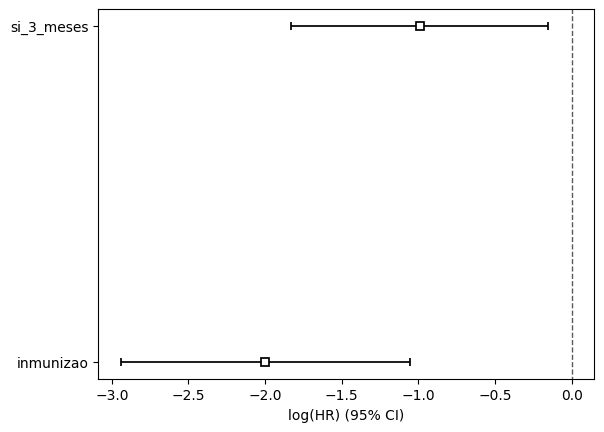

In [ ]:
ctv_upc3m = CoxTimeVaryingFitter()
ctv_upc3m.fit(df_upc3m, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv_upc3m.print_summary()
ctv_upc3m.plot()

coef_01 = ctv_upc3m.params_
conf_01 = ctv_upc3m.confidence_intervals_

hazard_ratios_01 = 1-np.exp(coef_01)
hazard_ratios_conf_int_01 = 1-np.exp(conf_01)
print(hazard_ratios_01)
print(hazard_ratios_conf_int_01)